In [1]:
from google.colab import files

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

uploaded = files.upload()

csv_files = [
    name
    for name in uploaded
    if name.lower().endswith(".csv")
]

if len(csv_files) != 1:
    raise ValueError(
        f"Upload exactly one CSV file. Files found: {list(uploaded.keys())}"
    )

file_name = csv_files[0]

df = pd.read_csv(
    io.BytesIO(uploaded[file_name]),
    encoding="utf-8-sig"
)

df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Roads:", df["street_name"].nunique())

df.head()

Saving selected_delhi_roads_hourly.csv to selected_delhi_roads_hourly.csv
Shape: (4800, 12)
Date range: 2024-08-11 00:00:00 to 2024-08-30 00:00:00
Roads: 10


,date,street_name,hour,day_of_week,day_number,is_weekend,is_peak_hour,probe_count,segment_count,average_speed_limit,average_frc,total_distance
0,2024-08-11,Mahatma Gandhi Marg,0,Sunday,6,1,0,285435,1052,52.443,1.5722,62245.45
1,2024-08-11,Mahatma Gandhi Marg,1,Sunday,6,1,0,238136,1052,52.443,1.5722,62245.45
2,2024-08-11,Mahatma Gandhi Marg,2,Sunday,6,1,0,181220,1052,52.443,1.5722,62245.45
3,2024-08-11,Mahatma Gandhi Marg,3,Sunday,6,1,0,141749,1052,52.443,1.5722,62245.45
4,2024-08-11,Mahatma Gandhi Marg,4,Sunday,6,1,0,125713,1052,52.443,1.5722,62245.45


In [2]:
print("COLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nDATASET INFORMATION")
df.info()

COLUMN NAMES
['date', 'street_name', 'hour', 'day_of_week', 'day_number', 'is_weekend', 'is_peak_hour', 'probe_count', 'segment_count', 'average_speed_limit', 'average_frc', 'total_distance']

DATA TYPES
date                   datetime64[ns]
street_name                    object
hour                            int64
day_of_week                    object
day_number                      int64
is_weekend                      int64
is_peak_hour                    int64
probe_count                     int64
segment_count                   int64
average_speed_limit           float64
average_frc                   float64
total_distance                float64
dtype: object

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 4800 non-null   datetime64[ns]
 1   street_name          4

In [3]:
missing_report = pd.DataFrame({
    "missing_values": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_report

,missing_values,missing_percentage
date,0,0.0
street_name,0,0.0
hour,0,0.0
day_of_week,0,0.0
day_number,0,0.0
is_weekend,0,0.0
is_peak_hour,0,0.0
probe_count,0,0.0
segment_count,0,0.0
average_speed_limit,0,0.0


In [4]:
exact_duplicates = df.duplicated().sum()

road_hour_duplicates = df.duplicated(
    subset=[
        "date",
        "street_name",
        "hour"
    ]
).sum()

print("Exact duplicate rows:", exact_duplicates)
print(
    "Duplicate date-road-hour combinations:",
    road_hour_duplicates
)

Exact duplicate rows: 0
Duplicate date-road-hour combinations: 0


In [5]:
completeness = (
    df.groupby("street_name")
    .size()
    .sort_values(ascending=False)
)

print(completeness)

print(
    "\nAll roads contain 480 observations:",
    bool((completeness == 480).all())
)

street_name
Africa Avenue             480
Aurobindo Marg            480
Barapullah Road           480
Mahatma Gandhi Marg       480
Mathura Road              480
Mehrauli Badarpur Road    480
Noida Link Road           480
Outer Ring Road           480
Sardar Patel Marg         480
Vikas Marg                480
dtype: int64

All roads contain 480 observations: True


In [6]:
numerical_columns = [
    "probe_count",
    "segment_count",
    "average_speed_limit",
    "average_frc",
    "total_distance"
]

summary_statistics = (
    df[numerical_columns]
    .describe()
    .T
)

summary_statistics

,count,mean,std,min,25%,50%,75%,max
probe_count,4800.0,107660.759375,124915.915519,2923.0000,31901.7500,51166.50000,140099.2500,616216.0000
segment_count,4800.0,411.400000,304.247802,114.0000,164.0000,294.00000,712.0000,1052.0000
average_speed_limit,4800.0,49.949430,2.595166,45.2661,48.2500,49.63560,52.4430,53.6082
average_frc,4800.0,2.062660,0.453023,1.3761,1.8783,1.99075,2.3947,3.0610
total_distance,4800.0,25452.733000,18614.010971,6981.2900,9624.0100,17220.76500,43347.7000,62245.4500


In [7]:
summary_statistics.to_csv(
    "eda_summary_statistics.csv"
)

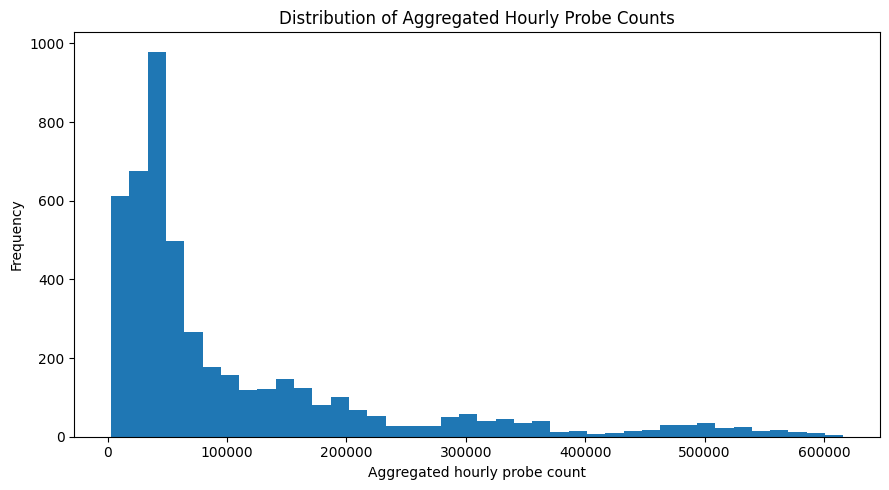

In [8]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["probe_count"],
    bins=40
)

plt.title(
    "Distribution of Aggregated Hourly Probe Counts"
)
plt.xlabel("Aggregated hourly probe count")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    "figure_probe_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

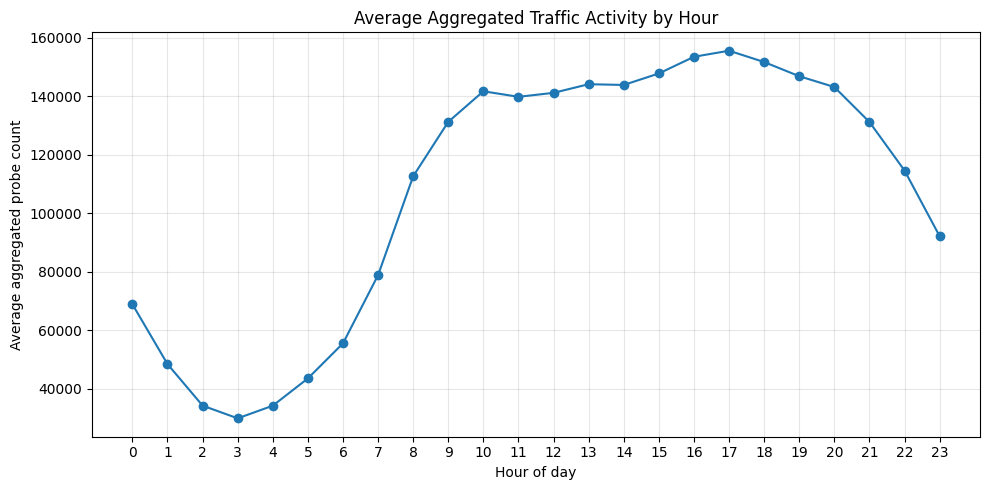

In [9]:
hourly_pattern = (
    df.groupby("hour")["probe_count"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values,
    marker="o"
)

plt.title(
    "Average Aggregated Traffic Activity by Hour"
)
plt.xlabel("Hour of day")
plt.ylabel("Average aggregated probe count")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figure_average_activity_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

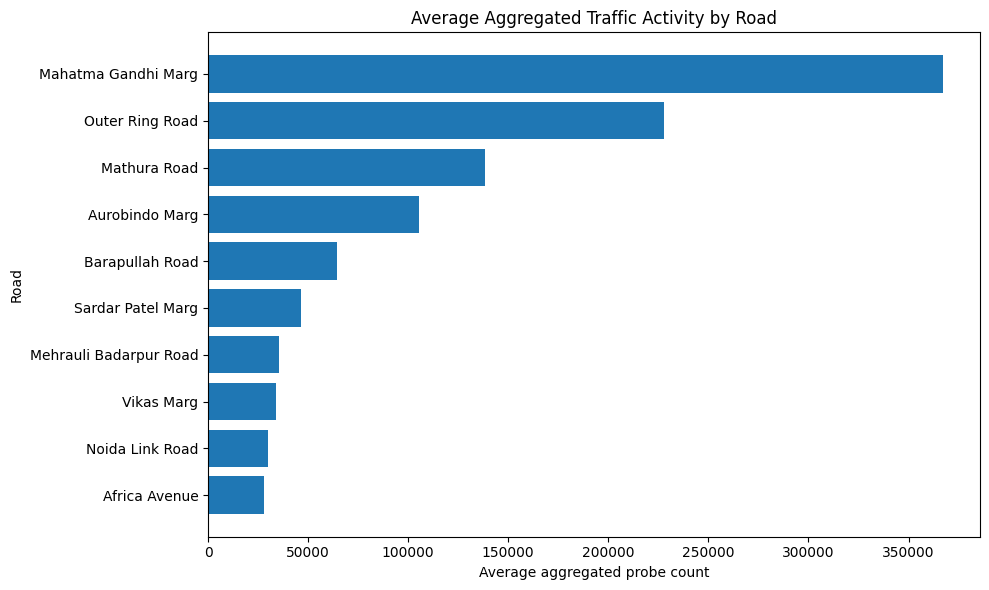

In [10]:
road_pattern = (
    df.groupby("street_name")["probe_count"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    road_pattern.index,
    road_pattern.values
)

plt.title(
    "Average Aggregated Traffic Activity by Road"
)
plt.xlabel("Average aggregated probe count")
plt.ylabel("Road")
plt.tight_layout()

plt.savefig(
    "figure_average_activity_by_road.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

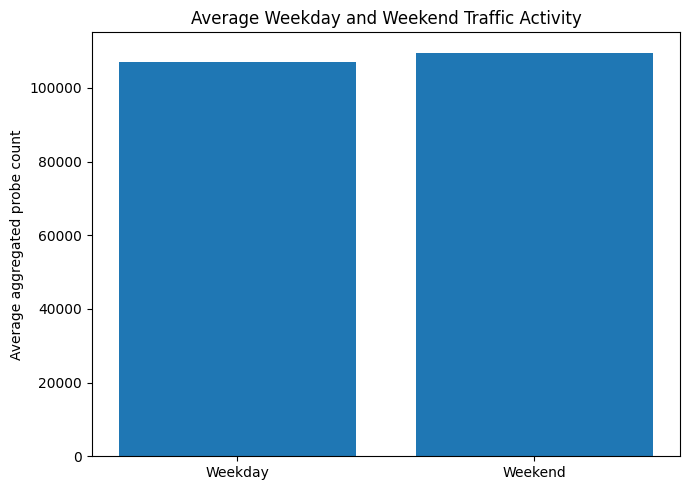

In [11]:
weekend_pattern = (
    df.groupby("is_weekend")["probe_count"]
    .mean()
)

labels = [
    "Weekday",
    "Weekend"
]

plt.figure(figsize=(7, 5))

plt.bar(
    labels,
    weekend_pattern.values
)

plt.title(
    "Average Weekday and Weekend Traffic Activity"
)
plt.ylabel("Average aggregated probe count")
plt.tight_layout()

plt.savefig(
    "figure_weekday_weekend_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

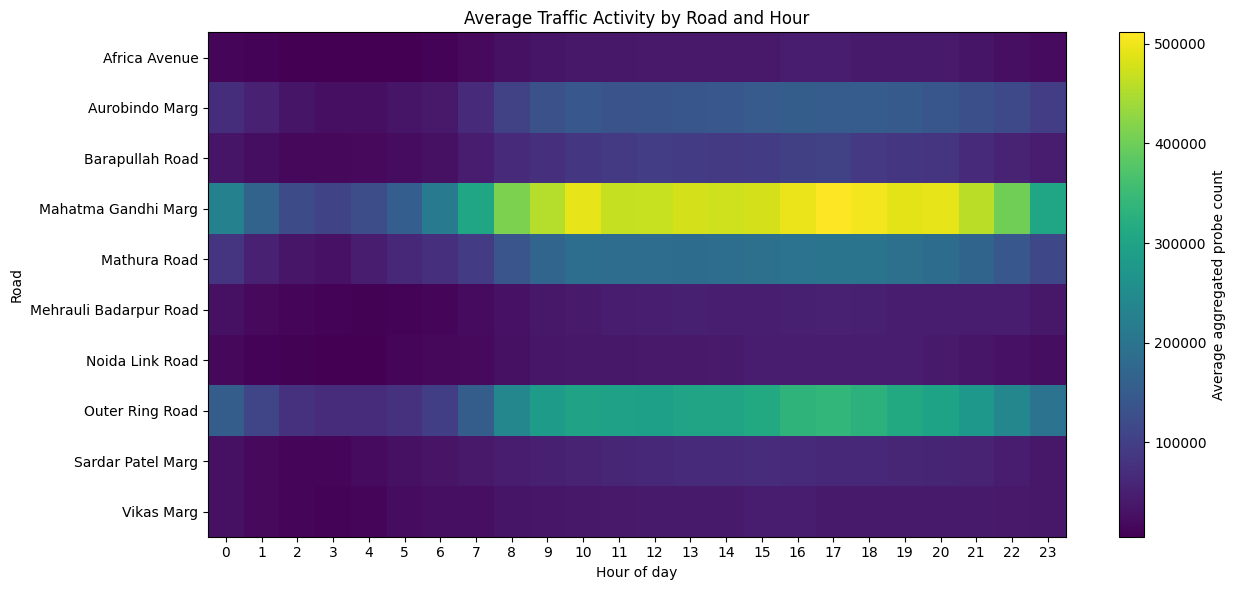

In [12]:
road_hour_matrix = df.pivot_table(
    index="street_name",
    columns="hour",
    values="probe_count",
    aggfunc="mean"
)

plt.figure(figsize=(13, 6))

plt.imshow(
    road_hour_matrix.values,
    aspect="auto"
)

plt.colorbar(
    label="Average aggregated probe count"
)

plt.xticks(
    range(24),
    range(24)
)

plt.yticks(
    range(len(road_hour_matrix.index)),
    road_hour_matrix.index
)

plt.title(
    "Average Traffic Activity by Road and Hour"
)
plt.xlabel("Hour of day")
plt.ylabel("Road")
plt.tight_layout()

plt.savefig(
    "figure_road_hour_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
from google.colab import files

output_files = [
    "eda_summary_statistics.csv",
    "figure_probe_count_distribution.png",
    "figure_average_activity_by_hour.png",
    "figure_average_activity_by_road.png",
    "figure_weekday_weekend_comparison.png",
    "figure_road_hour_activity.png"
]

for output_file in output_files:
    files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>